In [1]:
# !rm -rf '/content/DIS_Hughen'
# !git clone https://github.com/NU-Academics/DIS_Hughen.git

In [2]:
import numpy as np
import pandas as pd
import shap
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
df = pd.read_csv("undersampled_CIC2019_dataset.csv")
# df = pd.read_csv("/content/DIS_Hughen/undersampled_CIC2019_dataset.csv")

In [5]:
df.shape

(4685611, 90)

In [6]:
df_sample = df.copy()
df_sample = df_sample.drop(columns=["flowid"])
df_sample["label"] = df_sample["label"].apply(lambda x: 0 if x == "BENIGN" else 1)
X = df_sample.drop(columns=["label"]).select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]

In [7]:
print(df_sample["label"].value_counts())

label
1    4632334
0      53277
Name: count, dtype: int64


In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

tensor([[-0.1279, -0.3281, -0.1887,  ..., -0.5012, -0.4991, -0.5007],
        [-0.1279, -0.3281, -0.2285,  ..., -0.5012, -0.4991, -0.5007],
        [-0.1279, -0.3281, -0.2634,  ..., -0.5012, -0.4991, -0.5007],
        ...,
        [-0.1279, -0.3281, -0.1887,  ..., -0.5010, -0.4989, -0.5005],
        [-0.1279,  0.5752,  0.3618,  ...,  2.2192,  2.2210,  2.2193],
        [ 0.4693, -0.2330, -0.1774,  ..., -0.3861, -0.3840, -0.3856]],
       dtype=torch.float64)

In [13]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=128)

In [14]:
input_size = 88
hidden_size = 64
num_classes = 2

class BinaryClassDNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

In [15]:
model = BinaryClassDNN(input_size=X_train.shape[1]).to(device)
pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

In [18]:
num_epochs = 30
best_loss = float('inf')
patience = 5
counter = 0
for epoch in range(num_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            val_loss += criterion(logits, y_batch).item()
    val_loss /= len(val_loader)
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break
torch.save(model.state_dict(), "binaryclass_dnn.pth")

Epoch 1, Loss: 0.0001
Epoch 2, Loss: 0.0064
Epoch 3, Loss: 0.0002
Epoch 4, Loss: 0.0041
Epoch 5, Loss: 0.0002
Epoch 6, Loss: 0.0037
Epoch 7, Loss: 0.0003
Epoch 8, Loss: 0.0061
Epoch 9, Loss: 0.0001
Epoch 10, Loss: 0.0006
Epoch 11, Loss: 0.0001
Early stopping


In [19]:
model.eval()
X_tensor = X_val_tensor.to(device)
y = y_val.values
with torch.no_grad():
    logits = model(X_tensor)
    y_prob = torch.sigmoid(logits).cpu().numpy().squeeze()
    y_pred = (y_prob >= 0.5).astype(int)

PermutationExplainer explainer: 1001it [00:57, 17.21it/s]                                                              


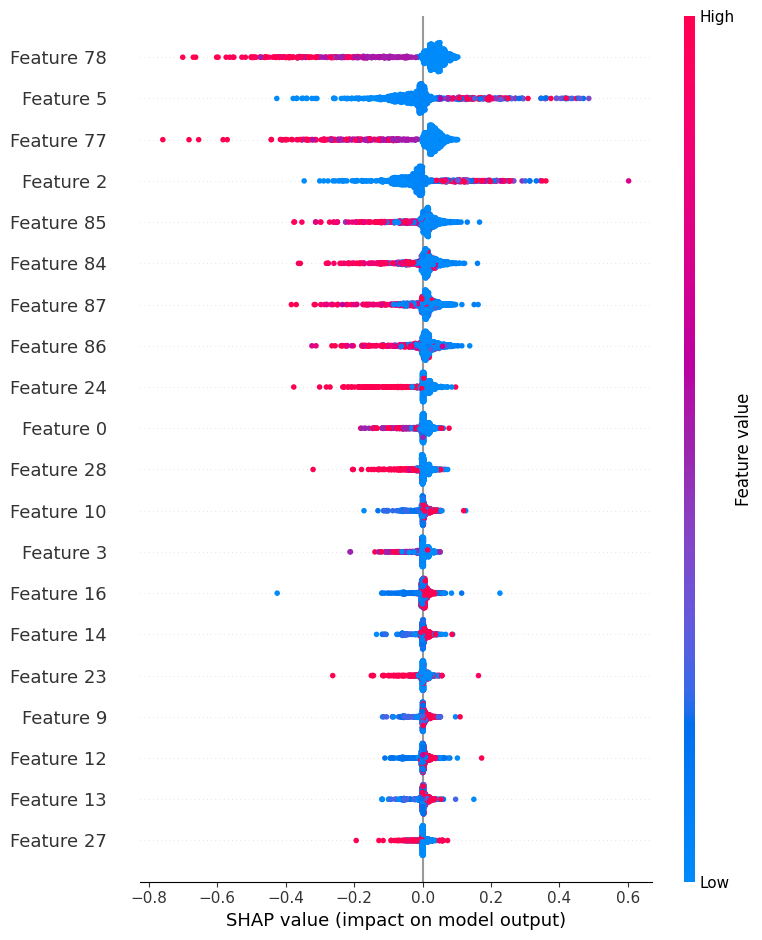

In [20]:
def predict_fn(X):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if not isinstance(X, np.ndarray):
        X = X.values
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    with torch.no_grad():
        outputs = torch.sigmoid(model(X_tensor))
    return outputs.cpu().numpy()
    
rng = np.random.default_rng(42)
X_sample = X.sample(1000, random_state=42).values
explainer = shap.Explainer(predict_fn, X_sample)
shap_values = explainer(X_sample)
shap.summary_plot(shap_values, X_sample, rng=rng)

In [21]:
print("Accuracy:", accuracy_score(y, y_pred))
print("Weighted F1:", f1_score(y, y_pred, average='weighted'))
print("Macro F1:", f1_score(y, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.9981368507655879
Weighted F1: 0.9982065190238086
Macro F1: 0.9616640811280914
ROC-AUC: 0.9999383402745128


In [22]:
print(classification_report(y, y_pred, target_names=["BENIGN", "ATTACK"]))

              precision    recall  f1-score   support

      BENIGN       0.86      1.00      0.92     10655
      ATTACK       1.00      1.00      1.00    926468

    accuracy                           1.00    937123
   macro avg       0.93      1.00      0.96    937123
weighted avg       1.00      1.00      1.00    937123

